# POKEMON

### Analitika kitabxanalarının yüklənməsi və Datasetin Gətirilməsi

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel('Pokemon.xlsx')
df.head(3)

,#,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male
0,1,Bulbasaur,grass,poison,318,45,49,49,65,65,45,0.7,6.9,0,1,45,70,88.1
1,2,Ivysaur,grass,poison,405,60,62,63,80,80,60,1.0,13.0,0,1,45,70,88.1
2,3,Venusaur,grass,poison,625,80,100,123,122,120,80,2.0,100.0,0,1,45,70,88.1


Datasetdə ən çox yayılmış Pokemon növü hansıdır? Bu tip nə qədər Pokemon var?

In [51]:
most_common_type = df['type1'].value_counts().idxmax()
count = df['type1'].value_counts().max()

print(f'Ən çox yayılmış Pokemon növü: {most_common_type}')
print(f'Bu tipdə olan Pokemon sayı: {count}')

Ən çox yayılmış Pokemon növü: water
Bu tipdə olan Pokemon sayı: 114


#### Digər növləri ilə müqayisədə həddindən artıq yüksək və ya aşağı statistikaya malik hər hansı Pokemon varmı?

In [52]:
q1 = df['base_total'].quantile(0.25)
q3 = df['base_total'].quantile(0.75)
iqr = q3-q1
lower = q1-1.5*iqr
upper = q3+1.5*iqr
outliers = df[(df['base_total'] < lower) | (df['base_total'] > upper)]

print(f'Həddindən artıq yüksək və ya aşağı statistikaya malik Pokemon sayı: {len(outliers)}')
outliers[['name', 'type1', 'base_total', 'is_legendary']].sort_values(by='base_total', ascending=False).head()

Həddindən artıq yüksək və ya aşağı statistikaya malik Pokemon sayı: 0


,name,type1,base_total,is_legendary


#### Pokemonun capture rate ilə onun base total arasında əlaqə varmı? Bəs onun nadirliyi (legendary və ya deyil)?

capture rate ilə onun base total arasında korrelyasiya: -0.71


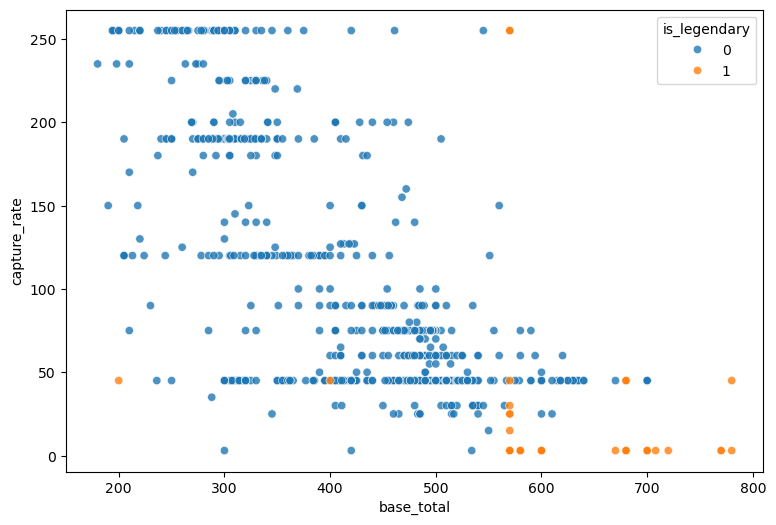

In [53]:
corr = df[['capture_rate', 'base_total']].corr().iloc[0,1]
print(f'capture rate ilə onun base total arasında korrelyasiya: {corr:.2f}')

plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='base_total', y='capture_rate', hue='is_legendary', alpha=0.8)
plt.show()

#### Hansı Pokemon ən yüksək hücum statistikasına malikdir?

In [54]:
# highest_attack = df.sort_values(by='attack', ascending=False).iloc[0]
# print(highest_attack['name'], highest_attack['attack'])

highest_attack = df.loc[df['attack'].idxmax()]
print(f'ən yüksək hücum statistikasına malik Pokemon: {highest_attack['name']} (hücum: {highest_attack['attack']})')

ən yüksək hücum statistikasına malik Pokemon: Heracross (hücum: 185)


#### Base total ilə HP, Attack, Defense, Special Attack, Special Defense və Speed kimi digər atributların hər biri arasında correlation nədir?

In [55]:
cols = ['base_total', 'hp', 'attack', 'defense', 'speed']
corr = df[cols].corr()

base_total_corr = corr[['base_total']].sort_values(by='base_total', ascending=False)
print('Base total ilə digər statistikalar arasındakı korrelyasiya: ')
print(base_total_corr)

Base total ilə digər statistikalar arasındakı korrelyasiya: 
            base_total
base_total    1.000000
attack        0.729998
defense       0.630151
hp            0.621062
speed         0.547575


#### Əfsanəvi və əfsanəvi olmayan Pokemonun ortalama hücum  arasında əhəmiyyətli fərq varmı?

In [57]:
avg_attack_legendary = df.groupby('is_legendary')['attack'].mean()
print('AVVVVVVVERRRRRRRRRRAAAAAAAAAAGEEEEEEEEEEEEE ATTTTTTTTTAAAAAAAAAAAAAAACK: ')
print(f'əfsanəvi olmayan: {avg_attack_legendary[0]:.2f}')
print(f'əfsanəvi olan: {avg_attack_legendary[1]:.2f}')

AVVVVVVVERRRRRRRRRRAAAAAAAAAAGEEEEEEEEEEEEE ATTTTTTTTTAAAAAAAAAAAAAAACK: 
əfsanəvi olmayan: 74.81
əfsanəvi olan: 109.36


#### Hansı tip 1 və tip 2 kombinasiyaları Pokemonlar arasında ən çox yayılmışdır?

In [58]:
type_combo = df.dropna(subset=['type2']).groupby(['type1', 'type2']).size().sort_values(ascending=False)
most_common = type_combo.index[0]
print(f'ən çox yayılmış kombinasiya: {most_common[0]} | {most_common[1]}')

ən çox yayılmış kombinasiya: normal | flying


#### Pokemonun çəkisi və boyu arasında korrelyasiya varmı?

In [59]:
corr = df[['weight_kg', 'height_m']].corr().iloc[0,1]
print(f'Pokemonun çəkisi və boyu arasında korrelyasiya: {corr:.2f}')

Pokemonun çəkisi və boyu arasında korrelyasiya: 0.63


#### Hansı nəsil (generation) ən yüksək ortalama sürətə malikdir?

In [61]:
fastest_gen = df.groupby('generation')['speed'].mean().sort_values(ascending=False)
print(f'ən yüksək ortalama sürətə malik nəsil: gen {fastest_gen.index[0]} və ortalama sürət {fastest_gen.iloc[0]:.2f}')

ən yüksək ortalama sürətə malik nəsil: gen 1 və ortalama sürət 70.15


#### Base total paylanması əfsanəvi və əfsanəvi olmayan Pokemon arasında necə dəyişir?

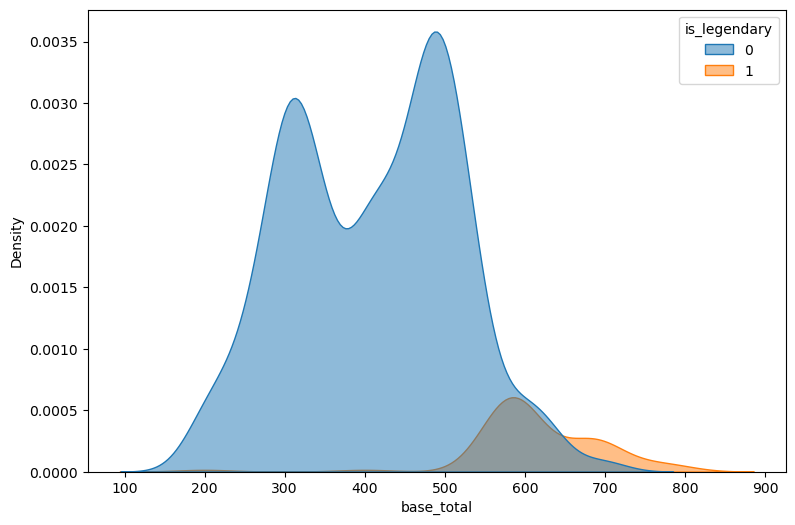

In [62]:
plt.figure(figsize=(9,6))
sns.kdeplot(data=df, x='base_total', hue='is_legendary', fill=True, alpha=0.5)
plt.show()

#### Müxtəlif Pokemon tipləri arasında Defense paylanmasında əhəmiyyətli fərq varmı?

C:\Users\User\AppData\Local\Temp\ipykernel_2184\3929373020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type1', y='defense', palette="mako")


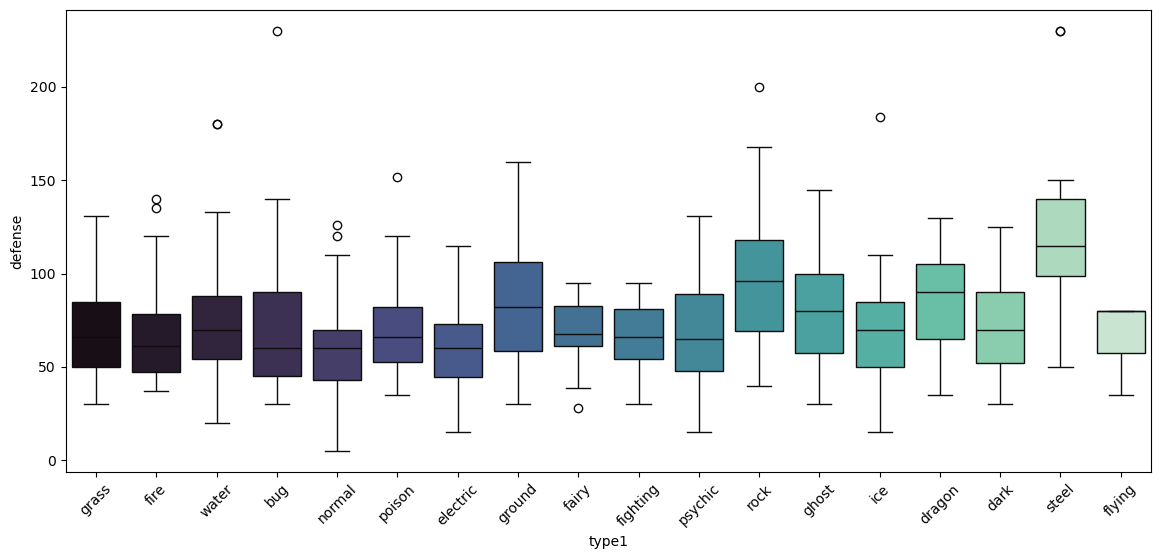

In [63]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='type1', y='defense', palette="mako")
plt.xticks(rotation=45)
plt.show()

#### Pokemonun adını input kimi qəbul edən və onun statistikalarının olduğu lüğətini qaytaran funksiya yazın.

In [73]:
def get_pokemon_stats():
    pokemon_name = input("Zəhmət olmasa Pokemon adını daxil edin: ")
    found_pokemon = df[df['name'].str.lower() == pokemon_name.lower()]
    
    if len(found_pokemon) > 0:
        data = found_pokemon.iloc[0]
        stats_dict = {
            'hp': data['hp'],
            'attack': data['attack'],
            'defense': data['defense'],
            'sp_attack': data['sp_attack'],
            'sp_defense': data['sp_defense'],
            'speed': data['speed'],
            'base_total': data['base_total']
        }
        return stats_dict
    else:
        return 'Belə bir Pokemon tapılmadı.'
        
get_pokemon_stats()

Zəhmət olmasa Pokemon adını daxil edin:  peremen


'Belə bir Pokemon tapılmadı.'

#### Percentage_male sütununda boş dəyərləri öz tipinin ortalaması ilə doldurun

In [74]:
type_mean = df.groupby('type1')['percentage_male'].mean()
df['percentage_male'] = df['percentage_male'].fillna(df['type1'].map(type_mean))

#### Daha çox kişiyə yaxın olan pokemonlar daha güclüdür, yoxsa qadına yaxın olanlar?

In [79]:
male = df[df['percentage_male'] > 50]['base_total'].mean()
female = df[df['percentage_male'] < 50]['base_total'].mean()

print(f'kişiyə yaxın olan pokemonların ortalama gücü: {male:.2f}')
print(f'qadına yaxın olan pokemonların ortalama gücü: {female:.2f}')

kişiyə yaxın olan pokemonların ortalama gücü: 470.66
qadına yaxın olan pokemonların ortalama gücü: 437.41


#### Əfsanəvi və ya əfsanəvi olmayan pokemonların ortalama çəkiləri və boyları arasında önəmli bir fərq var?

In [76]:
legendary_size = df.groupby('is_legendary')[['weight_kg', 'height_m']].mean()
print('ortalama çəki və boy: ')
print(legendary_size)

ortalama çəki və boy:
               weight_kg  height_m
is_legendary                      
0              48.018425  1.056681
1             199.350725  2.281159


#### Hansı tip1 və tip2 kombinasiyası daha xoşbəxtdir?

In [77]:
happy = df.dropna(subset=['type2']).groupby(['type1', 'type2'])['base_happiness'].mean().reset_index()
top_happy = happy.sort_values(by='base_happiness', ascending=False)

print('top 3 xoşbəxt kombinasiya: ')
print(top_happy.head(3))

top 3 xoşbəxt kombinasiya: 
    type1  type2  base_happiness
65  grass  grass           100.0
49   fire  steel           100.0
50   fire  water           100.0


#### Tiplər üzrə ortalama çəki və boyları tapın

In [28]:
avg_size = df.groupby('type1')[['weight_kg', 'height_m']].mean().sort_values(by='weight_kg', ascending=False)
avg_size.head(10)

,weight_kg,height_m
type1,,
steel,188.841667,1.875000
ground,150.044444,1.340741
dragon,107.125926,1.937037
ice,103.260870,1.208696
rock,94.270000,1.330000
ghost,69.570370,1.251852
dark,69.096552,1.296552
fire,66.096000,1.168000
fighting,58.675000,1.196429


### Mən oynamaq üçün ən ideal pokemonu seçmək istəsəm, hansını seçməliyəm? Bunun üçün özünüzə uyğun xüsusi bir analiz aparın və seçdiyiniz pokemonu əsaslandırın

In [40]:
# əfsanəvi olmayanları seçirik
non_legends = df[df['is_legendary'] == 0].copy()

# attack gücü (Attack və ya Sp.Attack hansı böyükdürsə) və sürətin cəmi (Sweeper Score)
non_legends['max_attack_stat'] = non_legends[['attack', 'sp_attack']].max(axis=1)
non_legends['sweeper_score'] = non_legends['max_attack_stat'] + non_legends['speed']

# top 3 namizəd
top_candidates = non_legends.sort_values(by=['sweeper_score', 'base_total'], ascending=False).head(3)

print("Təklif edilən İdeal Pokemonlar (Əfsanəvi olmayan 'Sweeper'lar):")
display(top_candidates[['name', 'type1', 'type2', 'max_attack_stat', 'speed', 'sweeper_score', 'base_total']])

ideal_pokemon = top_candidates.iloc[0]['name']
print(f"\nƏsaslandırma: Mənim analizimə görə {ideal_pokemon} mükəmməl seçimdir. Çünki oyunda ilk hücum etmək (Speed) və rəqibi tək vuruşda məğlub etmək (Max Attack) ən effektiv strategiyadır. Bu Pokemon əfsanəvi olmadığı üçün oyunda əldə edilə biləndir, lakin statistikaları əfsanəvilərlə rəqabət aparacaq qədər yüksəkdir.")

Təklif edilən İdeal Pokemonlar (Əfsanəvi olmayan 'Sweeper'lar):


,name,type1,type2,max_attack_stat,speed,sweeper_score,base_total
64,Alakazam,psychic,NaN,175,150,325,600
93,Gengar,ghost,poison,170,130,300,600
14,Beedrill,bug,poison,150,145,295,495



Əsaslandırma: Mənim analizimə görə Alakazam mükəmməl seçimdir. Çünki oyunda ilk hücum etmək (Speed) və rəqibi tək vuruşda məğlub etmək (Max Attack) ən effektiv strategiyadır. Bu Pokemon əfsanəvi olmadığı üçün oyunda əldə edilə biləndir, lakin statistikaları əfsanəvilərlə rəqabət aparacaq qədər yüksəkdir.


#### Apardığınız analizlərin nəticəsinə uyğun olaraq vizuallaşdırmalar aparın və bir dashboard qurun

C:\Users\User\AppData\Local\Temp\ipykernel_2184\3612754711.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_types.values, y=top_types.index, palette="mako", ax=axes[0, 1], alpha=0.9)


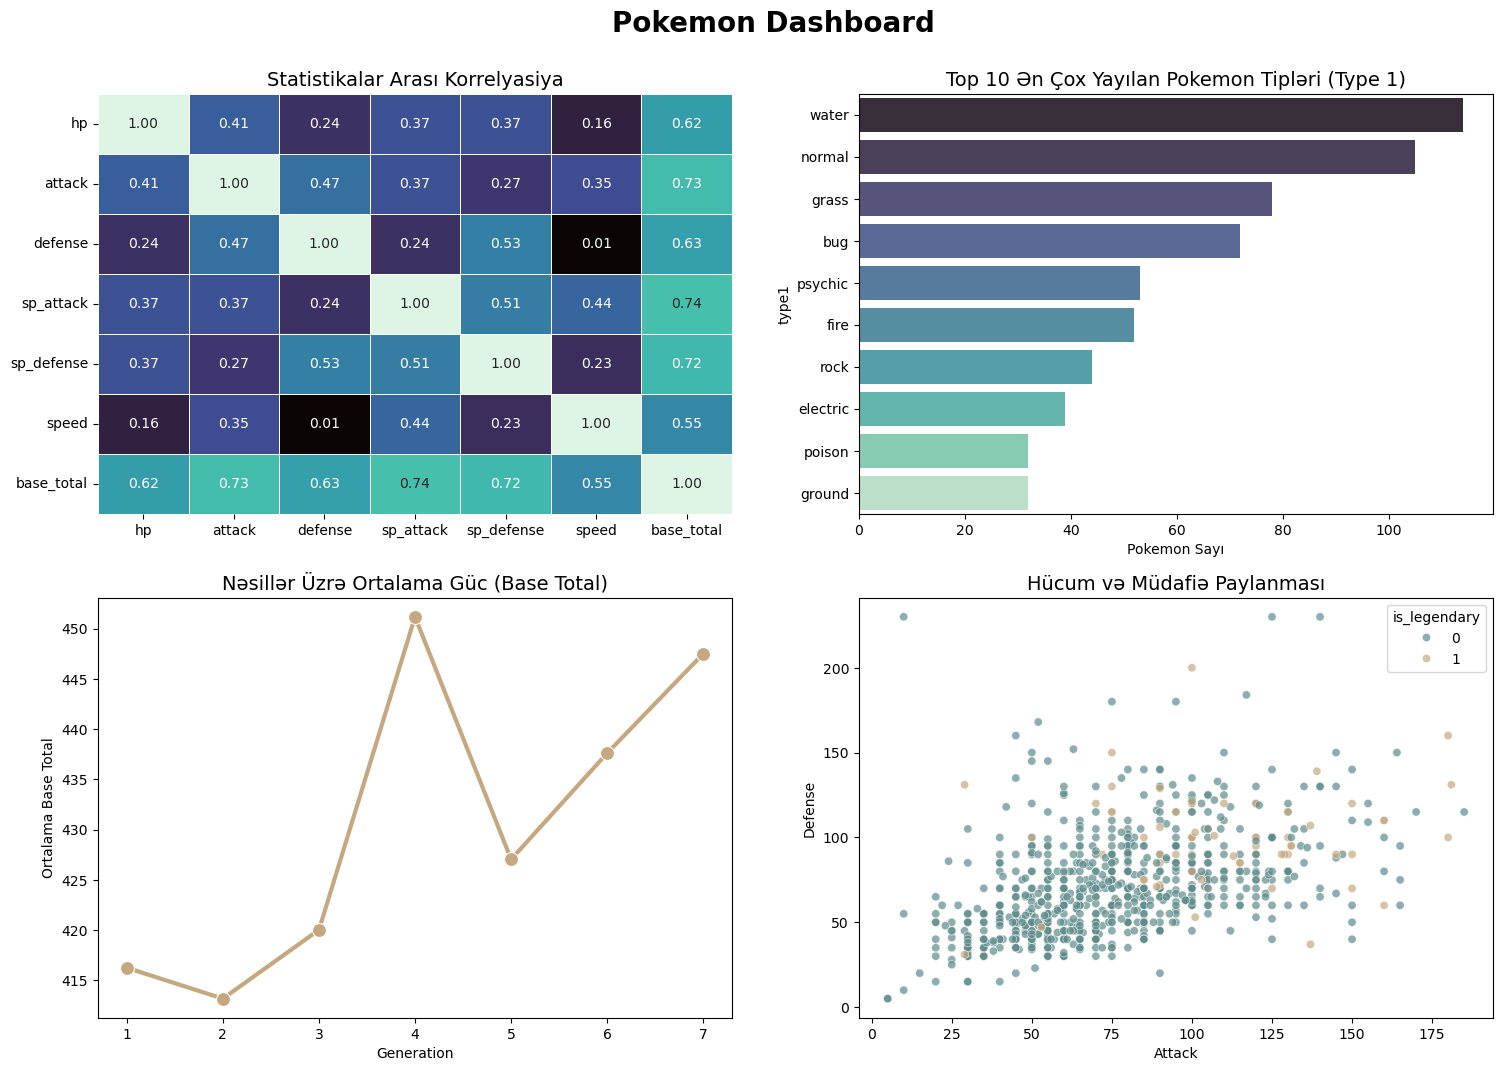

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Pokemon Dashboard', fontsize=20, fontweight='bold', y=0.95)

# korrelyasiya heatmap-i (Base stats arasında)
corr = df[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total']].corr()
sns.heatmap(corr, annot=True, cmap="mako", fmt=".2f", linewidths=0.5, ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Statistikalar Arası Korrelyasiya', fontsize=14)

# top 10 ən çox yayılan tiplər
top_types = df['type1'].value_counts().head(10)
sns.barplot(x=top_types.values, y=top_types.index, palette="mako", ax=axes[0, 1], alpha=0.9)
axes[0, 1].set_title('Top 10 Ən Çox Yayılan Pokemon Tipləri (Type 1)', fontsize=14)
axes[0, 1].set_xlabel('Pokemon Sayı')

# generations üzrə ortalama Base Total
gen_stats = df.groupby('generation')['base_total'].mean()
sns.lineplot(x=gen_stats.index, y=gen_stats.values, color="#C5A880", marker="o", linewidth=3, markersize=10, ax=axes[1, 0])
axes[1, 0].set_title('Nəsillər Üzrə Ortalama Güc (Base Total)', fontsize=14)
axes[1, 0].set_xlabel('Generation')
axes[1, 0].set_ylabel('Ortalama Base Total')

# legendary vs non-legendary attack və defense (Scatter)
sns.scatterplot(data=df, x='attack', y='defense', hue='is_legendary', palette=["#5E8C8A", "#C5A880"], alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Hücum və Müdafiə Paylanması', fontsize=14)
axes[1, 1].set_xlabel('Attack')
axes[1, 1].set_ylabel('Defense')

plt.show()